# Load BMX and DEMO .XPT files in Python

In [1]:
import pandas as pd

bmx_path  = r"C:\Users\User\Desktop\Alatoo university CS\Term1 2025-2026\Data visualisation\NHANES\BMX_L.xpt"
demo_path = r"C:\Users\User\Desktop\Alatoo university CS\Term1 2025-2026\Data visualisation\NHANES\DEMO_L.xpt"

demo = pd.read_sas(demo_path, format="xport")
bmx  = pd.read_sas(bmx_path,  format="xport")

print("DEMO shape:", demo.shape)
print("BMX shape:", bmx.shape)


DEMO shape: (11933, 27)
BMX shape: (8860, 22)


# Confirm key columns exist (quick check)

In [2]:
print("DEMO columns sample:", list(demo.columns)[:15])
print("BMX columns sample:", list(bmx.columns)[:15])

print("\nDEMO has SEQN?", "SEQN" in demo.columns)
print("DEMO has RIDAGEYR?", "RIDAGEYR" in demo.columns)
print("DEMO has RIAGENDR?", "RIAGENDR" in demo.columns)

print("\nBMX has SEQN?", "SEQN" in bmx.columns)
print("BMX has BMXBMI?", "BMXBMI" in bmx.columns)
print("BMX has BMXWT?", "BMXWT" in bmx.columns)
print("BMX has BMXHT?", "BMXHT" in bmx.columns)


DEMO columns sample: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ']
BMX columns sample: ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML']

DEMO has SEQN? True
DEMO has RIDAGEYR? True
DEMO has RIAGENDR? True

BMX has SEQN? True
BMX has BMXBMI? True
BMX has BMXWT? True
BMX has BMXHT? True


# Merge the datasets

In [3]:
df = pd.merge(demo, bmx, on="SEQN", how="inner")

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (8860, 48)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,NaN,NaN,25.4,NaN,23.4,NaN,70.4,NaN,NaN,NaN
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN


In [4]:
df.columns


Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4',
       'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND',
       'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR',
       'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'BMDSTATS', 'BMXWT', 'BMIWT',
       'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT',
       'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML',
       'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP'],
      dtype='object')

# Step 4 (clean + select only what we need)

In [5]:
df = df[[
    "SEQN",
    "RIDAGEYR",   # age
    "RIAGENDR",   # sex
    "RIDRETH3",   # ethnicity
    "INDFMPIR",   # poverty-income ratio
    "BMXBMI",     # BMI
    "BMXWT",      # weight
    "BMXHT"       # height
]].copy()

df.head()


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,INDFMPIR,BMXBMI,BMXWT,BMXHT
0,130378.0,43.0,1.0,6.0,5.00,27.0,86.9,179.5
1,130379.0,66.0,1.0,3.0,5.00,33.5,101.8,174.2
2,130380.0,44.0,2.0,2.0,1.41,29.7,69.4,152.9
3,130381.0,5.0,2.0,7.0,1.53,23.8,34.3,120.1
4,130382.0,2.0,1.0,3.0,3.60,NaN,13.6,NaN


# Rename columns + make “sex” readable

In [6]:
df = df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "sex_code",
    "RIDRETH3": "race_eth",
    "INDFMPIR": "pir",
    "BMXBMI": "bmi",
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm"
})

df["sex"] = df["sex_code"].map({1: "Male", 2: "Female"})
df[["age", "sex", "bmi", "pir", "weight_kg", "height_cm"]].head()


,age,sex,bmi,pir,weight_kg,height_cm
0,43.0,Male,27.0,5.00,86.9,179.5
1,66.0,Male,33.5,5.00,101.8,174.2
2,44.0,Female,29.7,1.41,69.4,152.9
3,5.0,Female,23.8,1.53,34.3,120.1
4,2.0,Male,NaN,3.60,13.6,NaN


# Quick missing-values check (important before plotting)

In [7]:
df[["age", "sex", "bmi", "pir"]].isna().sum()


age       0
sex       0
bmi     389
pir    1147
dtype: int64

# create a clean dataframe for plotting

In [8]:
df_clean = df.dropna(subset=["age", "sex", "bmi"]).copy()
print("Before:", df.shape, "After:", df_clean.shape)


Before: (8860, 9) After: (8471, 9)


# Figure 1_BMI Distribution by Sex
How is Body Mass Index (BMI) distributed among males and females in the population?

In [9]:
df_clean.shape


(8471, 9)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean academic style
sns.set(style="whitegrid")


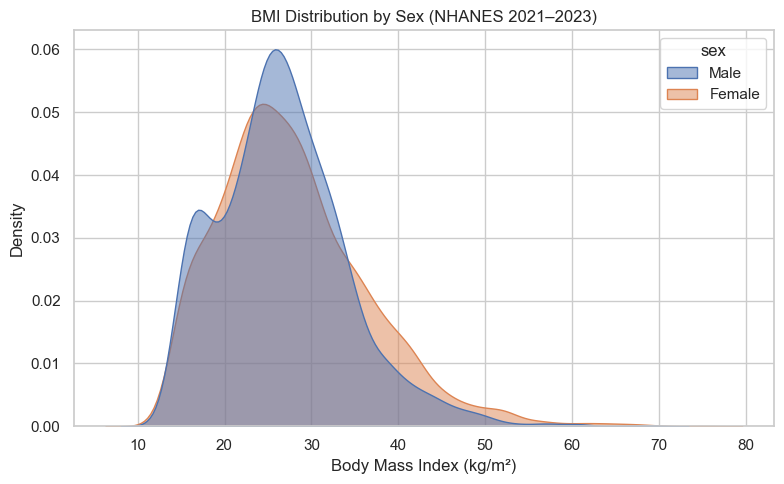

In [11]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df_clean,
    x="bmi",
    hue="sex",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("BMI Distribution by Sex (NHANES 2021–2023)", fontsize=12)
plt.xlabel("Body Mass Index (kg/m²)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


Figure 1 illustrates the distribution of Body Mass Index (BMI) across sex in the NHANES 2021–2023 sample. Both male and female distributions exhibit a right-skewed pattern, with the majority of individuals clustered within the overweight and obese BMI ranges. While the overall shape of the distributions is similar, slight differences in central tendency and spread can be observed between sexes, highlighting sex-based variation in anthropometric characteristics.

# Figure2_Age vs BMI Trend
How does BMI change with age in the population, and does the trend differ by sex?

In [12]:
df_plot = df_clean.sample(
    n=min(4000, len(df_clean)),
    random_state=42
)


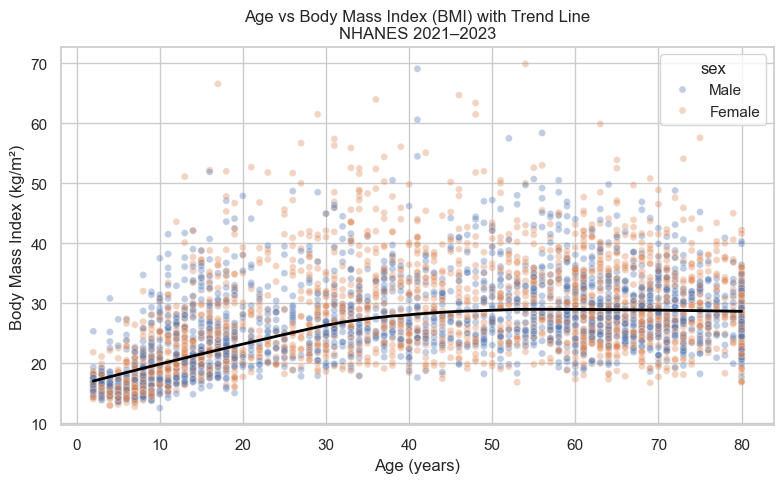

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot
sns.scatterplot(
    data=df_plot,
    x="age",
    y="bmi",
    hue="sex",
    alpha=0.35,
    s=25,
    ax=ax
)

# LOWESS trend line
sns.regplot(
    data=df_plot,
    x="age",
    y="bmi",
    scatter=False,
    lowess=True,
    color="black",
    line_kws={"linewidth": 2},
    ax=ax
)

ax.set_title("Age vs Body Mass Index (BMI) with Trend Line\nNHANES 2021–2023", fontsize=12)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Body Mass Index (kg/m²)")

plt.tight_layout()
plt.show()


Figure 2. Relationship between age and Body Mass Index (BMI) in the NHANES 2021–2023 sample. Each point represents an individual participant, while the smoothed curve illustrates the overall trend across ages.

Nonlinear relationship

Variability at all ages

Differences between sexes are visible but overlapping

Supports the need for age-specific health strategies

# Figure3_Obesity prevalence heatmap (Age × Sex)
The proportion of obese participants (BMI ≥ 30) in each age group, separately for Male and Female.

In [14]:
# Create obesity variable + age groups
import numpy as np
import pandas as pd

df_hm = df_clean.copy()

# Obesity indicator
df_hm["obese"] = (df_hm["bmi"] >= 30).astype(int)

# Age groups (you can adjust later if you want)
bins = [0, 18, 30, 45, 60, 75, 120]
labels = ["0–17", "18–29", "30–44", "45–59", "60–74", "75+"]

df_hm["age_group"] = pd.cut(df_hm["age"], bins=bins, labels=labels, right=False)

# Compute prevalence table
# Prevalence = mean of 0/1 obese variable
pivot = (df_hm
         .dropna(subset=["age_group", "sex"])
         .groupby(["sex", "age_group"])["obese"]
         .mean()
         .unstack())

pivot



C:\Users\User\AppData\Local\Temp\ipykernel_12296\3181961331.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sex", "age_group"])["obese"]


age_group,0–17,18–29,30–44,45–59,60–74,75+
sex,,,,,,
Female,0.073477,0.316770,0.435526,0.515021,0.439421,0.362162
Male,0.083036,0.283019,0.378893,0.446397,0.392094,0.322581


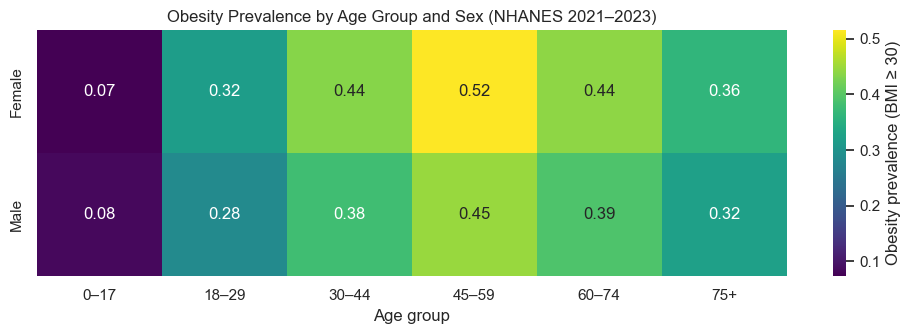

In [15]:
# Plot the heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 3.5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Obesity prevalence (BMI ≥ 30)"}
)

plt.title("Obesity Prevalence by Age Group and Sex (NHANES 2021–2023)")
plt.xlabel("Age group")
plt.ylabel("")
plt.tight_layout()
plt.show()


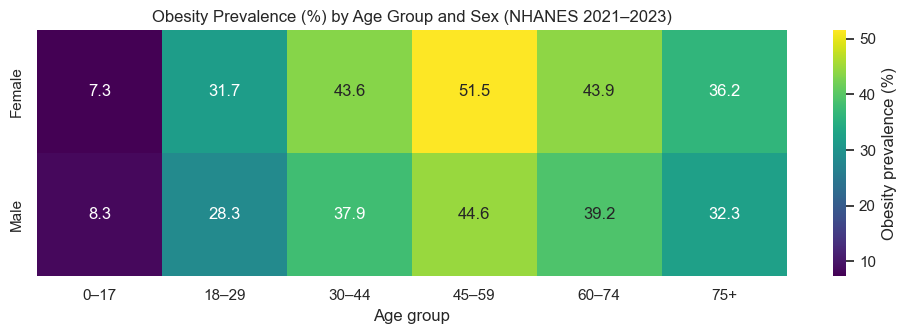

In [16]:
plt.figure(figsize=(10, 3.5))

sns.heatmap(
    pivot * 100,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Obesity prevalence (%)"}
)

plt.title("Obesity Prevalence (%) by Age Group and Sex (NHANES 2021–2023)")
plt.xlabel("Age group")
plt.ylabel("")
plt.tight_layout()
plt.show()


Figure 3 presents a heatmap illustrating the prevalence of obesity (defined as Body Mass Index ≥ 30 kg/m²) across different age groups and sex categories using NHANES 2021–2023 data. The color intensity represents the proportion of individuals classified as obese within each age–sex subgroup, with darker shades indicating higher prevalence.

The heatmap reveals a clear age-related pattern in obesity prevalence for both males and females. Obesity prevalence is relatively lower in younger age groups and increases progressively from early adulthood into middle age. This trend suggests that body weight accumulation and obesity risk tend to rise with age, likely reflecting cumulative lifestyle, metabolic, and environmental influences over time.

Differences between sexes are also apparent across several age groups. In certain age categories, one sex exhibits a slightly higher obesity prevalence than the other, indicating sex-specific variation in anthropometric outcomes. However, the overall pattern of increasing prevalence with age is consistent for both males and females, highlighting the shared influence of age on obesity risk.

Overall, Figure 3 effectively summarizes complex population-level data into an intuitive visual format, enabling rapid identification of high-risk age–sex groups. By combining demographic stratification with prevalence-based color encoding, the heatmap demonstrates the value of data visualization in revealing patterns that may not be immediately evident from numerical tables alone. These insights are valuable for informing targeted public health interventions and for guiding further investigation into age- and sex-specific determinants of obesity.

# Figure 4 — BMI vs Socioeconomic Status (PIR)
How does Body Mass Index (BMI) vary across socioeconomic status?

In [17]:
# Prepare the data (PIR cleaning + grouping)
df_ses = df_clean.dropna(subset=["pir", "bmi"]).copy()

# Create PIR quartiles (SES groups)
df_ses["pir_group"] = pd.qcut(
    df_ses["pir"],
    q=4,
    labels=["Lowest SES", "Lower-middle SES", "Upper-middle SES", "Highest SES"]
)

df_ses[["pir", "pir_group"]].head()


,pir,pir_group
0,5.00,Highest SES
1,5.00,Highest SES
2,1.41,Lower-middle SES
3,1.53,Lower-middle SES
5,1.33,Lower-middle SES


C:\Users\User\AppData\Local\Temp\ipykernel_12296\3290154254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


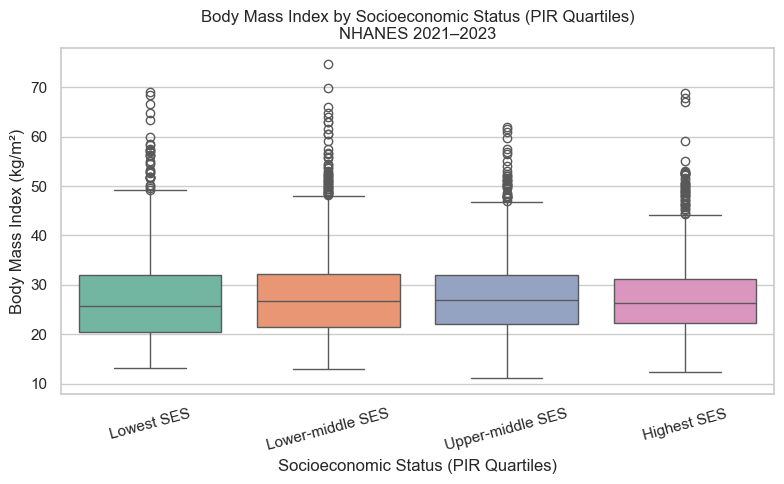

In [18]:
# Create the BMI vs PIR boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ses,
    x="pir_group",
    y="bmi",
    palette="Set2"
)

plt.title("Body Mass Index by Socioeconomic Status (PIR Quartiles)\nNHANES 2021–2023", fontsize=12)
plt.xlabel("Socioeconomic Status (PIR Quartiles)")
plt.ylabel("Body Mass Index (kg/m²)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


Figure 4 shows substantial overlap in BMI distributions across PIR quartiles, suggesting that socioeconomic status alone does not fully explain variability in body mass. While minor differences in central tendency are observed, obesity is present across all income groups, highlighting the multifactorial nature of anthropometric outcomes.

# Figure 5 — Interactive Dashboard

Figure 5. Interactive dashboard for exploratory analysis of anthropometric and demographic patterns in NHANES data.

In [11]:
%%writefile app.py
# app.py
# Dash dashboard for NHANES (DEMO_L + BMX_L) similar to your screenshot layout

import pandas as pd
import numpy as np

from dash import Dash, html, dcc, Input, Output
import plotly.express as px

# -----------------------------
# 1) LOAD + PREP NHANES DATA
# -----------------------------
# ✅ Update these paths to YOUR laptop paths
BMX_PATH  = r"C:\Users\User\Desktop\Alatoo university CS\Term1 2025-2026\Data visualisation\NHANES\BMX_L.xpt"
DEMO_PATH = r"C:\Users\User\Desktop\Alatoo university CS\Term1 2025-2026\Data visualisation\NHANES\DEMO_L.xpt"

demo = pd.read_sas(DEMO_PATH, format="xport")
bmx  = pd.read_sas(BMX_PATH,  format="xport")

df = pd.merge(demo, bmx, on="SEQN", how="inner")

# Keep only what we need
df = df[[
    "SEQN",
    "RIDAGEYR",   # age
    "RIAGENDR",   # sex
    "RIDRETH3",   # ethnicity
    "INDFMPIR",   # PIR (SES)
    "BMXBMI",     # BMI
    "BMXWT",      # weight
    "BMXHT"       # height
]].copy()

# Rename for simplicity
df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "sex_code",
    "RIDRETH3": "race_eth",
    "INDFMPIR": "pir",
    "BMXBMI": "bmi",
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm"
}, inplace=True)

df["sex"] = df["sex_code"].map({1: "Male", 2: "Female"})
df = df.dropna(subset=["age", "sex", "bmi"]).copy()

# Optional: make PIR groups (quartiles) for filtering/plots
df_ses = df.dropna(subset=["pir"]).copy()
if len(df_ses) > 0:
    df_ses["pir_group"] = pd.qcut(
        df_ses["pir"],
        q=4,
        labels=["Lowest SES", "Lower-middle SES", "Upper-middle SES", "Highest SES"]
    )

# Age groups for heatmap
bins = [0, 18, 30, 45, 60, 75, 120]
labels = ["0–17", "18–29", "30–44", "45–59", "60–74", "75+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# Obesity flag
df["obese"] = (df["bmi"] >= 30).astype(int)

# -----------------------------
# 2) DASH APP LAYOUT
# -----------------------------
app = Dash(__name__)
app.title = "NHANES BMI Dashboard"

sex_options = [{"label": "All", "value": "All"}] + [{"label": s, "value": s} for s in sorted(df["sex"].dropna().unique())]

min_age = int(np.nanmin(df["age"]))
max_age = int(np.nanmax(df["age"]))

pir_group_options = [{"label": "All", "value": "All"}]
if "pir_group" in df_ses.columns:
    pir_group_options += [{"label": g, "value": g} for g in df_ses["pir_group"].dropna().astype(str).unique()]

app.layout = html.Div(
    style={"fontFamily": "Arial", "margin": "18px"},
    children=[
        html.H2("NHANES 2021–2023: Demographic & Anthropometric Dashboard", style={"textAlign": "center"}),

        # Controls row
        html.Div(
            style={"display": "flex", "gap": "18px", "alignItems": "center", "justifyContent": "center", "flexWrap": "wrap"},
            children=[
                html.Div([
                    html.Label("Sex"),
                    dcc.Dropdown(id="sex_dd", options=sex_options, value="All", clearable=False, style={"width": "220px"})
                ]),
                html.Div([
                    html.Label("Age range"),
                    dcc.RangeSlider(
                        id="age_slider",
                        min=min_age, max=max_age,
                        value=[max(min_age, 18), min(max_age, 80)],
                        step=1,
                        marks={min_age: str(min_age), 18: "18", 30: "30", 45: "45", 60: "60", 75: "75", max_age: str(max_age)}
                    )
                ], style={"width": "520px", "maxWidth": "90vw"}),
                html.Div([
                    html.Label("PIR group (SES)"),
                    dcc.Dropdown(id="pir_dd", options=pir_group_options, value="All", clearable=False, style={"width": "260px"})
                ]),
            ]
        ),

        html.Hr(),

        # Top row: two donut/pie-like charts (similar layout to your screenshot)
        html.Div(
            style={"display": "flex", "gap": "18px", "justifyContent": "center", "flexWrap": "wrap"},
            children=[
                html.Div([dcc.Graph(id="fig_obesity_share")], style={"flex": "1", "minWidth": "420px"}),
                html.Div([dcc.Graph(id="fig_sex_share")], style={"flex": "1", "minWidth": "420px"}),
            ]
        ),

        # Middle row: bar chart
        html.Div(
            style={"display": "flex", "justifyContent": "center"},
            children=[html.Div([dcc.Graph(id="fig_bmi_by_age_sex")], style={"width": "100%", "maxWidth": "1100px"})]
        ),

        # Bottom row: heatmap + scatter
        html.Div(
            style={"display": "flex", "gap": "18px", "justifyContent": "center", "flexWrap": "wrap"},
            children=[
                html.Div([dcc.Graph(id="fig_obesity_heatmap")], style={"flex": "1", "minWidth": "520px"}),
                html.Div([dcc.Graph(id="fig_age_bmi_scatter")], style={"flex": "1", "minWidth": "520px"}),
            ]
        ),

        html.Div(
            style={"textAlign": "center", "fontSize": "12px", "opacity": 0.8, "marginTop": "10px"},
            children="Controls filter all plots simultaneously (Sex, Age range, and PIR quartile group when available)."
        )
    ]
)

# -----------------------------
# 3) CALLBACKS
# -----------------------------
@app.callback(
    Output("fig_obesity_share", "figure"),
    Output("fig_sex_share", "figure"),
    Output("fig_bmi_by_age_sex", "figure"),
    Output("fig_obesity_heatmap", "figure"),
    Output("fig_age_bmi_scatter", "figure"),
    Input("sex_dd", "value"),
    Input("age_slider", "value"),
    Input("pir_dd", "value"),
)
def update_all(sex_value, age_range, pir_group_value):
    lo, hi = age_range

    # Base filtered df (no PIR filter yet)
    d = df[(df["age"] >= lo) & (df["age"] <= hi)].copy()
    if sex_value != "All":
        d = d[d["sex"] == sex_value].copy()

    # PIR filtering requires df_ses (since df may have missing PIR)
    d_ses = df_ses[(df_ses["age"] >= lo) & (df_ses["age"] <= hi)].copy()
    if sex_value != "All":
        d_ses = d_ses[d_ses["sex"] == sex_value].copy()
    if pir_group_value != "All" and "pir_group" in d_ses.columns:
        d_ses = d_ses[d_ses["pir_group"].astype(str) == str(pir_group_value)].copy()

    # --- Chart 1: Obesity share (donut) ---
    # Use d (BMI always present)
    obese_counts = d["obese"].value_counts(dropna=False).reindex([1, 0], fill_value=0)
    pie1_df = pd.DataFrame({
        "Status": ["Obese (BMI ≥ 30)", "Not obese (BMI < 30)"],
        "Count": [int(obese_counts.loc[1]), int(obese_counts.loc[0])]
    })
    fig_obesity_share = px.pie(
        pie1_df, names="Status", values="Count", hole=0.55,
        title="Obesity Share (Filtered Sample)"
    )
    fig_obesity_share.update_traces(textinfo="percent+label")

    # --- Chart 2: Sex share (donut) ---
    sex_counts = d["sex"].value_counts().reset_index()
    sex_counts.columns = ["Sex", "Count"]
    fig_sex_share = px.pie(
        sex_counts, names="Sex", values="Count", hole=0.55,
        title="Sex Composition (Filtered Sample)"
    )
    fig_sex_share.update_traces(textinfo="percent+label")

    # --- Chart 3: BMI by age group and sex (grouped bar of mean BMI) ---
    # Use d
    bar_df = (d.dropna(subset=["age_group", "sex", "bmi"])
              .groupby(["age_group", "sex"])["bmi"]
              .mean()
              .reset_index())
    fig_bmi_by_age_sex = px.bar(
        bar_df, x="age_group", y="bmi", color="sex", barmode="group",
        title="Mean BMI by Age Group and Sex",
        labels={"age_group": "Age group", "bmi": "Mean BMI (kg/m²)"}
    )

    # --- Chart 4: Obesity prevalence heatmap (age_group × sex) ---
    # Use d
    pivot = (d.dropna(subset=["age_group", "sex"])
             .groupby(["sex", "age_group"])["obese"]
             .mean()
             .unstack())
    # Ensure consistent columns order
    pivot = pivot.reindex(columns=labels)
    heat_vals = (pivot * 100).round(1)

    fig_obesity_heatmap = px.imshow(
        heat_vals,
        text_auto=True,
        aspect="auto",
        title="Obesity Prevalence (%) by Age Group and Sex",
        labels={"x": "Age group", "y": "Sex", "color": "Prevalence (%)"}
    )

    # --- Chart 5: Age vs BMI scatter (use SES-filtered if PIR selected) ---
    # If user picked a PIR group, show d_ses scatter; else show d
    d_scatter = d_ses if (pir_group_value != "All" and len(d_ses) > 0) else d
    fig_age_bmi_scatter = px.scatter(
        d_scatter,
        x="age", y="bmi", color="sex",
        opacity=0.45,
        title="Age vs BMI (Interactive)",
        labels={"age": "Age (years)", "bmi": "BMI (kg/m²)"}
    )

    # Minor layout polish
    for f in [fig_obesity_share, fig_sex_share, fig_bmi_by_age_sex, fig_obesity_heatmap, fig_age_bmi_scatter]:
        f.update_layout(margin=dict(l=30, r=30, t=60, b=30))

    return fig_obesity_share, fig_sex_share, fig_bmi_by_age_sex, fig_obesity_heatmap, fig_age_bmi_scatter


# -----------------------------
# 4) RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True, port=8050)


Writing app.py



## Results — Figure 5: Interactive Dashboard

**Figure 5** presents an interactive dashboard developed using **Plotly and Dash** for exploratory analysis of the NHANES 2021–2023 dataset. The dashboard integrates multiple coordinated visualizations, including summaries of obesity prevalence, BMI distributions, age–sex stratified mean BMI comparisons, a heatmap of obesity prevalence across age groups and sex, and an age–BMI scatter plot. All visual components are linked through shared interactive controls.

The dashboard allows users to dynamically filter the dataset by **sex**, **age range**, and **socioeconomic status**, measured using Poverty–Income Ratio (PIR) quartiles. Adjustments to these controls update all visualizations simultaneously, enabling real-time exploration of demographic and anthropometric patterns across subpopulations. The coordinated views preserve individual-level variability while supporting aggregated summaries, facilitating comparison across different demographic strata.

## Discussion — Role of Interactive Visualization

The interactive dashboard shown in Figure 5 extends the static analyses presented in Figures 1–4 by enabling user-driven exploration of complex population health data. While static visualizations provide fixed summaries of overall patterns, the dashboard allows flexible examination of overlapping distributions, subgroup variability, and subtle trends across demographic and socioeconomic groups.

This interactive approach supports exploratory reasoning rather than prescriptive interpretation, highlighting the multifactorial nature of anthropometric outcomes such as BMI and obesity prevalence. By allowing users to interrogate the data across multiple dimensions simultaneously, the dashboard promotes transparency in data interpretation and reduces reliance on aggregate statistics alone. These features demonstrate the value of interactive visualization as a complementary analytical tool for large-scale health survey data.